In [52]:
import os
import openai
import random
from dotenv import load_dotenv, find_dotenv
_ = load_dotenv(find_dotenv())
openai.api_key = os.getenv("OPENAI_API_KEY")


In [53]:
from langgraph.graph import StateGraph, END
from typing import TypedDict, Annotated
import operator
from langchain_openai import ChatOpenAI
from langchain_core.messages import AnyMessage, SystemMessage, HumanMessage, ToolMessage
from langchain_openai import ChatOpenAI
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain.schema.output_parser import StrOutputParser
from IPython.display import Image, display
from typing import Literal



import json

In [54]:
class AgentState(TypedDict):
    messages: Annotated[list[AnyMessage], operator.add]

In [55]:
class Agent:
     def __init__(self, model ):
     
          self.model=model
          graph = StateGraph(AgentState)

          graph.add_node("Entrada", self.entrada)
          graph.add_node("Maçã", self.Maçã)
          graph.add_node("Banana", self.Banana)

          graph.set_entry_point("Entrada")
          graph.add_conditional_edges("Entrada", self.sortear, {
                "Maçã": "Maçã",      
                "Banana": "Banana"  
            } )
          graph.add_edge("Banana", END)
          graph.add_edge("Maçã", END)
          self.graph = graph.compile()
          png = self.graph.get_graph().draw_mermaid_png()
          display(Image(png))

     def entrada(self, state: AgentState):
          return state


     def sortear(self, state: AgentState):
         
          if random.random() < 0.5:
               return "Maçã"
          else: 
               return "Banana"
          
     def Maçã(self, state: AgentState):
          novo_state = {
               'messages' : state ['messages'] + [SystemMessage(content="Maçã")]
          }
          return self.resposta(novo_state)
     
     def Banana(self, state: AgentState):
          novo_state = {
               'messages' : state ['messages'] + [SystemMessage(content="Banana")]
          }
          return self.resposta(novo_state)
         

     def resposta(self, state: AgentState):     
          prompt = """Com base na fruta retornada, explique qual os principais benefícios da ingestão dela."""
          messages = state['messages']
          resposta = self.model.invoke([HumanMessage(content=prompt + " - " + state["messages"][-1].content)])

          mensagem_final = state["messages"][-1].content + " - " + resposta.content
          
          return {'messages': [mensagem_final]}
         

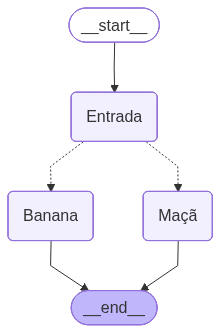

In [56]:


model = ChatOpenAI(model="gpt-4.1-mini", temperature=0)
chain = Agent(model)




In [57]:
entrada = {"messages": [HumanMessage]}
result = chain.graph.invoke(entrada)

In [58]:
result['messages'][-1]

'Banana - A banana é uma fruta muito popular e nutritiva, conhecida por seus diversos benefícios para a saúde. Aqui estão os principais benefícios da ingestão de banana:\n\n1. **Fonte de Energia Rápida**: A banana é rica em carboidratos, principalmente na forma de açúcares naturais (glicose, frutose e sacarose), que fornecem energia rápida e sustentável, sendo ideal para atletas e pessoas ativas.\n\n2. **Rica em Potássio**: A banana é uma excelente fonte de potássio, um mineral essencial para o funcionamento adequado dos músculos e do coração, ajudando a regular a pressão arterial e prevenir cãibras musculares.\n\n3. **Melhora a Digestão**: Contém fibras dietéticas, como a pectina, que auxiliam no bom funcionamento do intestino, prevenindo a constipação e promovendo a saúde digestiva.\n\n4. **Fonte de Vitaminas**: A banana fornece vitaminas importantes, como a vitamina C (antioxidante que fortalece o sistema imunológico) e vitaminas do complexo B (como a B6), que ajudam no metabolismo 